In [59]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kagglehub import KaggleDatasetAdapter

df_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "mexwell/employee-performance-and-productivity-data",
    "Extended_Employee_Performance_and_Productivity_Data.csv",
)

df_raw.head()


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [60]:
df_raw.set_index('Employee_ID', inplace=True)
print(f"Full dataset shape: {df_raw.shape}")
print()

print(f"  Rows (observations): {df_raw.shape[0]}")
print(f"  Columns (variables): {df_raw.shape[1]}")
print()
print(f"  Departments: {df_raw['Department'].unique()}")
print(f"  Job Titles: {df_raw['Job_Title'].unique()}")

df_raw.head()


Full dataset shape: (100000, 19)

  Rows (observations): 100000
  Columns (variables): 19

  Departments: ['IT' 'Finance' 'Customer Support' 'Engineering' 'Marketing' 'HR'
 'Operations' 'Sales' 'Legal']
  Job Titles: ['Specialist' 'Developer' 'Analyst' 'Manager' 'Technician' 'Engineer'
 'Consultant']


,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
Employee_ID,,,,,,,,,,,,,,,,,,,
1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [61]:
print("Column names and dtypes:")
print(df_raw.dtypes)
print()

Column names and dtypes:
Department                      object
Gender                          object
Age                              int64
Job_Title                       object
Hire_Date                       object
Years_At_Company                 int64
Education_Level                 object
Performance_Score                int64
Monthly_Salary                 float64
Work_Hours_Per_Week              int64
Projects_Handled                 int64
Overtime_Hours                   int64
Sick_Days                        int64
Remote_Work_Frequency            int64
Team_Size                        int64
Training_Hours                   int64
Promotions                       int64
Employee_Satisfaction_Score    float64
Resigned                          bool
dtype: object



In [62]:
df_raw["Job_Title"] = df_raw["Job_Title"].astype("string")
df_raw["Department"] = df_raw["Department"].astype("string")
df_raw["Education_Level"] = df_raw["Education_Level"].astype("string")
df_raw["Gender"] = df_raw["Gender"].astype("string")
df_raw["Gender"] = df_raw["Gender"].astype("string")
df_raw['Hire_Date'] = pd.to_datetime(df_raw['Hire_Date'])

In [63]:
print("Column names and dtypes:")
print(df_raw.dtypes)
print()

Column names and dtypes:
Department                     string[python]
Gender                         string[python]
Age                                     int64
Job_Title                      string[python]
Hire_Date                      datetime64[ns]
Years_At_Company                        int64
Education_Level                string[python]
Performance_Score                       int64
Monthly_Salary                        float64
Work_Hours_Per_Week                     int64
Projects_Handled                        int64
Overtime_Hours                          int64
Sick_Days                               int64
Remote_Work_Frequency                   int64
Team_Size                               int64
Training_Hours                          int64
Promotions                              int64
Employee_Satisfaction_Score           float64
Resigned                                 bool
dtype: object



Missing values per column:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

No missing values found in any column.


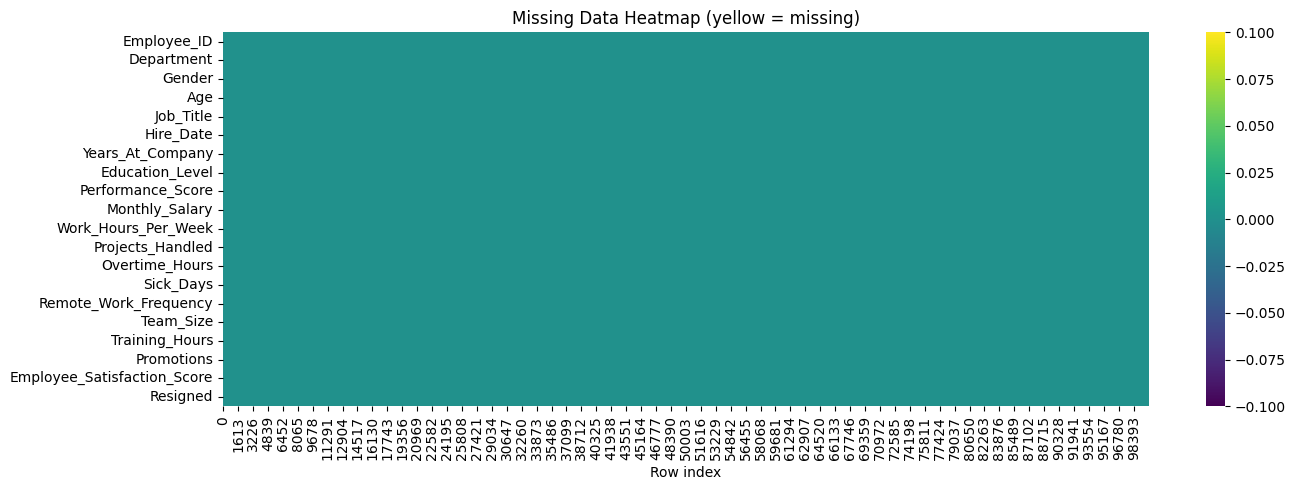


Rows with at least one missing value: 0 / 100000 (0.00%)


In [64]:
missing_counts = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
}).sort_values('missing_count', ascending=False)

print("Missing values per column:")
print(missing_summary[missing_summary['missing_count'] > 0])
print()
if missing_summary['missing_count'].sum() == 0:
    print("No missing values found in any column.")
else:
    print(f"Total missing values: {missing_summary['missing_count'].sum()}")

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df.isnull().T, cbar=True, yticklabels=True, cmap='viridis', ax=ax)
ax.set_title('Missing Data Heatmap (yellow = missing)')
ax.set_xlabel('Row index')
plt.tight_layout()
plt.show()

rows_with_missing = df.isnull().any(axis=1).sum()
print(f"\nRows with at least one missing value: {rows_with_missing} / {len(df)} "
      f"({rows_with_missing / len(df):.2%})")

In [80]:
Global_Satisfaction_df = pd.read_csv('Global-Satisfaction.csv')
Global_Satisfaction_df.head()
Job_Satisfaction_df = pd.read_csv('Job-Satisfaction.csv')
Job_Satisfaction_df.head()
Organization_Satisfaction_df = pd.read_csv('Organization-Satisfaction.csv')
Organization_Satisfaction_df.head()
Pay_Satisfaction_df = pd.read_csv('Pay-Satisfaction.csv')
Pay_Satisfaction_df.head()
Recommend_Organization_df = pd.read_csv('Recommend-Organization.csv')
Recommend_Organization_df.head()

,Agency Name,Agency Size,percentage_2024,percentage_2023,percentage_2022,percentage_2021,percentage_2020
0,Governmentwide,NaN,65,64,62,64,69
1,Very Large Agencies Overall,NaN,65,NaN,NaN,NaN,NaN
2,Department of Agriculture,Very Large,63,61,59,59,64
3,"Department of Defense, Overall",Very Large,65,64,62,64,70
4,United States Department of the Air Force,Very Large,65,65,63,63,69


,Agency Name,Agency Size,percentage_2024,percentage_2023,percentage_2022,percentage_2021,percentage_2020
0,Governmentwide,NaN,69,68,66,67,72
1,Very Large Agencies Overall,NaN,69,NaN,NaN,NaN,NaN
2,Department of Agriculture,Very Large,69,67,65,65,68
3,"Department of Defense, Overall",Very Large,70,68,67,67,72
4,United States Department of the Air Force,Very Large,69,69,68,66,72


,Agency Name,Agency Size,percentage_2024,percentage_2023,percentage_2022,percentage_2021,percentage_2020
0,Governmentwide,NaN,64,62,60,61,66
1,Very Large Agencies Overall,NaN,63,NaN,NaN,NaN,NaN
2,Department of Agriculture,Very Large,62,60,57,56,59
3,"Department of Defense, Overall",Very Large,64,63,61,61,67
4,United States Department of the Air Force,Very Large,63,65,63,62,67


,Agency Name,Agency Size,percentage_2024,percentage_2023,percentage_2022,percentage_2021,percentage_2020
0,Governmentwide,NaN,59,57,56,61,67
1,Very Large Agencies Overall,NaN,59,NaN,NaN,NaN,NaN
2,Department of Agriculture,Very Large,51,48,48,53,63
3,"Department of Defense, Overall",Very Large,60,59,57,62,68
4,United States Department of the Air Force,Very Large,58,58,56,58,66


,Agency Name,Agency Size,percentage_2024,percentage_2023,percentage_2022,percentage_2021,percentage_2020
0,Governmentwide,NaN,69,67,65,67,71
1,Very Large Agencies Overall,NaN,69,NaN,NaN,NaN,NaN
2,Department of Agriculture,Very Large,70,68,65,64,67
3,"Department of Defense, Overall",Very Large,69,67,65,67,71
4,United States Department of the Air Force,Very Large,68,68,66,67,71


In [81]:
df6 = pd.read_csv('demographics_by_agency.xlsx')

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa3 in position 15: invalid start byte